In [1]:
# Cell 1 - Install dependencies
!pip -q install h5py opencv-python-headless scipy scikit-learn pandas matplotlib seaborn

In [2]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [3]:
# Cell 2 - Imports and reproducibility
from pathlib import Path
import json
import os
import random
import shutil
import time
import zipfile

import cv2
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from scipy.io import loadmat
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
AUGMENT_TRAIN = True  # False: train without augmentation; validation/test never augment
EPOCHS = 50
LEARNING_RATE = 1e-3
CLASS_NAMES = ["glioma", "meningioma", "pituitary tumor"]
RAW_LABEL_TO_CLASS_INDEX = {1: 1, 2: 0, 3: 2}

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except (AttributeError, RuntimeError):
    pass

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:
# Cell 3 - Load data
from pathlib import Path

RAW_DIR = Path(
    "/kaggle/input/datasets/lenguytueminh/braintumordatapublic"
)

mat_files = sorted(
    p for p in RAW_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() == ".mat"
    and p.name.lower() != "cvind.mat"
)

print(f"Found {len(mat_files)} .mat files")

# Thư mục lưu kết quả
WORK_DIR = Path("/kaggle/working/brain_tumor_project")
OUTPUT_DIR = WORK_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Found 3064 .mat files


In [5]:
# Cell 4 - MATLAB loading and inventory creation
def scalar(value):
    array = np.asarray(value).squeeze()
    return array.item() if array.size == 1 else array

def patient_id(value):
    array = np.asarray(value).squeeze()
    # Nếu PID được lưu dưới dạng mảng mã ASCII (như [49, 49, 50, ...])
    if array.dtype.kind in {"i", "u"}:
        # Xử lý trường hợp mảng có thể có nhiều chiều hoặc chỉ có 1 phần tử
        if array.ndim > 0:
            return "".join(chr(int(item)) for item in array)
        else:
            return chr(int(array))
    return str(scalar(array)).strip()

def load_case(path):
    try:
        # Thử đọc bằng định dạng MATLAB tiêu chuẩn (v7 trở xuống)
        mat = loadmat(path, squeeze_me=True, struct_as_record=False)
        cjdata = mat["cjdata"]
        return {
            "label": np.asarray(getattr(cjdata, "label")),
            "PID": np.asarray(getattr(cjdata, "PID")),
            "image": np.asarray(getattr(cjdata, "image")),
            "tumorMask": np.asarray(getattr(cjdata, "tumorMask"))
        }
    except NotImplementedError:
        # Thử đọc bằng định dạng HDF5 (MATLAB v7.3)
        with h5py.File(path, "r") as mat:
            if "cjdata" in mat:
                group = mat["cjdata"]
            else:
                group = mat

            # Đọc các trường dữ liệu một cách an toàn
            # Đối với HDF5, MATLAB lưu ma trận xoay 90 độ, do đó cần áp dụng .T
            return {
                "label": np.asarray(group["label"]).T,
                "PID": np.asarray(group["PID"]).T,
                "image": np.asarray(group["image"]).T,
                "tumorMask": np.asarray(group["tumorMask"]).T
            }
# Loại file phụ trợ khỏi danh sách ảnh MRI
mat_files = [
    path for path in mat_files
    if path.name.lower() != "cvind.mat"
]

print(f"Số file còn lại: {len(mat_files):,}")
rows = []
for path in mat_files:
    try:
        case = load_case(path)
        raw_label = int(scalar(case["label"]))
        if raw_label not in RAW_LABEL_TO_CLASS_INDEX:
            raise ValueError(f"Invalid label in {path.name}: {raw_label}")
        class_index = RAW_LABEL_TO_CLASS_INDEX[raw_label]
        rows.append({
            "file": str(path.relative_to(RAW_DIR)),
            "class_index": class_index,
            "class_name": CLASS_NAMES[class_index],
            "patient_id": patient_id(case["PID"]),
        })
    except Exception as e:
        print(f"Lỗi khi xử lý file {path.name}: {e}")
        raise e

inventory = pd.DataFrame(rows)
print(inventory.groupby("class_name").size())
print("Patients:", inventory["patient_id"].nunique())

Số file còn lại: 3,064
class_name
glioma             1426
meningioma          708
pituitary tumor     930
dtype: int64
Patients: 233


In [6]:
# Cell 5 - Deterministic patient-level stratified split
def make_split(frame, seed=42):
    rng = np.random.default_rng(seed)
    assignments = []
    for class_index, group in frame.groupby("class_index", sort=True):
        patients = np.array(sorted(group["patient_id"].unique()), dtype=object)
        rng.shuffle(patients)
        train_end = int(round(len(patients) * 0.70))
        validation_end = train_end + int(round(len(patients) * 0.15))
        for pid in patients[:train_end]:
            assignments.append((int(class_index), str(pid), "train"))
        for pid in patients[train_end:validation_end]:
            assignments.append((int(class_index), str(pid), "validation"))
        for pid in patients[validation_end:]:
            assignments.append((int(class_index), str(pid), "test"))
    split_patients = pd.DataFrame(assignments, columns=["class_index", "patient_id", "split"])
    result = frame.merge(split_patients, on=["class_index", "patient_id"], validate="many_to_one")
    for left, right in (("train", "validation"), ("train", "test"), ("validation", "test")):
        if set(result.loc[result.split == left, "patient_id"]) & set(result.loc[result.split == right, "patient_id"]):
            raise RuntimeError("Patient leakage detected")
    return result

# Create ONE shared manifest here. All three models reuse it; do not split in model cells.
manifest = make_split(inventory, SEED)
manifest.to_csv(OUTPUT_DIR / "split_manifest.csv", index=False)
print(pd.crosstab(manifest["split"], manifest["class_name"]))

class_name  glioma  meningioma  pituitary tumor
split                                          
test           228         114              159
train          968         485              618
validation     230         109              153


In [7]:
# Cell 6 - Image preprocessing and tf.data pipelines
def prepare_image(image, mask, image_size=224):
    image = np.asarray(image)
    mask = np.asarray(mask)
    maximum = float(np.max(image))
    if maximum > 0:
        threshold = np.uint8(image.astype(np.float32) > maximum * 0.05) * 255
        kernel = np.ones((5, 5), dtype=np.uint8)
        foreground = cv2.morphologyEx(threshold, cv2.MORPH_CLOSE, kernel)
        contours, _ = cv2.findContours(foreground, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
            image, mask = image[y:y+h, x:x+w], mask[y:y+h, x:x+w]
    resized = cv2.resize(image, (image_size, image_size), interpolation=cv2.INTER_AREA).astype(np.float32)
    low, high = float(resized.min()), float(resized.max())
    normalized = (resized - low) / (high - low) if high > low else np.zeros_like(resized)
    return np.repeat(normalized[..., None], 3, axis=-1).astype(np.float32)

def sample_generator(frame):
    for row in frame.itertuples(index=False):
        case = load_case(RAW_DIR / row.file)
        image = prepare_image(case["image"], case["tumorMask"], IMAGE_SIZE)
        label = np.eye(len(CLASS_NAMES), dtype=np.float32)[int(row.class_index)]
        yield image, label

def augment_image(image, label):
    # Same operations and order as src/data_loader.py::_augment_batch.
    image = tf.image.random_brightness(image, max_delta=0.08)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    image = tf.image.random_flip_left_right(image)
    return tf.clip_by_value(image, 0.0, 1.0), label


def make_dataset(split, *, augment=False):
    if split not in {"train", "validation", "test"}:
        raise ValueError(f"Unknown split: {split}")
    if augment and split != "train":
        raise ValueError("Augmentation is only allowed for the train split")
    frame = manifest[manifest.split == split].reset_index(drop=True)
    if frame.empty:
        raise ValueError(f"Empty split: {split}")
    dataset = tf.data.Dataset.from_generator(
        lambda: sample_generator(frame),
        output_signature=(
            tf.TensorSpec((IMAGE_SIZE, IMAGE_SIZE, 3), tf.float32),
            tf.TensorSpec((len(CLASS_NAMES),), tf.float32),
        ),
    )
    dataset = dataset.apply(tf.data.experimental.assert_cardinality(len(frame)))
    # Training is shuffled even when augmentation is disabled for an ablation.
    if split == "train":
        dataset = dataset.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    if augment:
        dataset = dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Shared datasets for all three models; rebuilding these does not change the manifest.
train_ds = make_dataset("train", augment=AUGMENT_TRAIN)
validation_ds = make_dataset("validation", augment=False)
test_ds = make_dataset("test", augment=False)


I0000 00:00:1791453724.237181      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791453724.240790      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [8]:
# Cell 7 - Simple CNN from scratch
def build_simple_cnn():
    inputs = tf.keras.Input((IMAGE_SIZE, IMAGE_SIZE, 3))
    x = inputs

    for filters in (32, 64, 128):
        x = tf.keras.layers.Conv2D(
            filters, 3, padding="same", activation="relu"
        )(x)
        x = tf.keras.layers.Conv2D(
            filters, 3, padding="same", activation="relu"
        )(x)
        x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(3, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name="simple_cnn")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = build_simple_cnn()
model.summary()
summary_lines = []
model.summary(print_fn=summary_lines.append)
(OUTPUT_DIR / "simple_cnn_summary.txt").write_text("\n".join(summary_lines), encoding="utf-8")


Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303,907 (1.16 MB)

 Trainable params: 303,907 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

2588

In [12]:
# Cell 8 - Train from scratch; keep the best validation checkpoint
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

LEARNING_RATE = 1e-3
model = build_simple_cnn()

train_ds = make_dataset("train", augment=AUGMENT_TRAIN)
validation_ds = make_dataset("validation", augment=False)
test_ds = make_dataset("test", augment=False)

checkpoint_path = OUTPUT_DIR / "simple_cnn_6conv_patience10_best.keras"


class ValidationMetrics(tf.keras.callbacks.Callback):
    def __init__(self, dataset):
        super().__init__()
        self.dataset = dataset

    def on_epoch_end(self, epoch, logs=None):
        y_true, y_pred = [], []

        for images, labels in self.dataset:
            probabilities = self.model(images, training=False)
            y_true.extend(np.argmax(labels.numpy(), axis=1))
            y_pred.extend(np.argmax(probabilities.numpy(), axis=1))

        report = classification_report(
            y_true,
            y_pred,
            labels=[0, 1, 2],
            target_names=CLASS_NAMES,
            output_dict=True,
            zero_division=0,
        )

        metrics = {
            "val_macro_f1": report["macro avg"]["f1-score"],
            **{
                f"val_recall_{name.replace(' ', '_')}": report[name]["recall"]
                for name in CLASS_NAMES
            },
        }

        if logs is not None:
            logs.update(metrics)

        print("\n" + " | ".join(
            f"{name}: {value:.4f}" for name, value in metrics.items()
        ))


callbacks = [
    ValidationMetrics(validation_ds),

    tf.keras.callbacks.ModelCheckpoint(
        str(checkpoint_path),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
]

print("Initial LR:", float(
    tf.keras.backend.get_value(model.optimizer.learning_rate)
))
print("Parameters:", model.count_params())

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

pd.DataFrame(history.history).to_json(
    OUTPUT_DIR / "simple_cnn_6conv_patience10_history.json"
)

Initial LR: 0.0010000000474974513
Parameters: 303907
Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.4537 - loss: 1.0841
val_macro_f1: 0.2124 | val_recall_glioma: 1.0000 | val_recall_meningioma: 0.0000 | val_recall_pituitary_tumor: 0.0000

Epoch 1: val_loss improved from None to 1.05321, saving model to /kaggle/working/brain_tumor_project/outputs/simple_cnn_6conv_patience10_best.keras

Epoch 1: finished saving model to /kaggle/working/brain_tumor_project/outputs/simple_cnn_6conv_patience10_best.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 83s 519ms/step - accuracy: 0.4635 - loss: 1.0743 - val_accuracy: 0.4675 - val_loss: 1.0532 - val_macro_f1: 0.2124 - val_recall_glioma: 1.0000 - val_recall_meningioma: 0.0000e+00 - val_recall_pituitary_tumor: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.4640 - loss: 1.0603
val_macro_f1: 0.2124 | val_recall_glioma: 1.0000 | val_recall_meningioma: 0.0000 | val_recall_pituitary_tumor: 0.0000

E

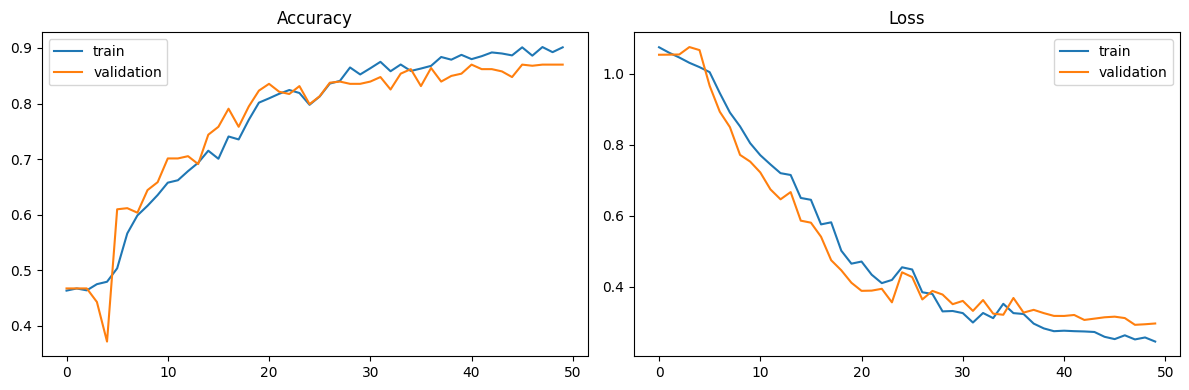

16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 845ms/step
{
  "accuracy": 0.812375249500998,
  "macro_precision": 0.7829458264282515,
  "macro_recall": 0.7898598698002869,
  "macro_f1": 0.7813419844912168,
  "per_class_metrics": {
    "glioma": {
      "precision": 0.9393939393939394,
      "recall": 0.8157894736842105,
      "f1-score": 0.8732394366197183,
      "support": 228.0
    },
    "meningioma": {
      "precision": 0.6226415094339622,
      "recall": 0.5789473684210527,
      "f1-score": 0.6,
      "support": 114.0
    },
    "pituitary tumor": {
      "precision": 0.7868020304568528,
      "recall": 0.9748427672955975,
      "f1-score": 0.8707865168539326,
      "support": 159.0
    }
  },
  "parameter_count": 303907,
  "inference_time": 0.02720387617564901
}


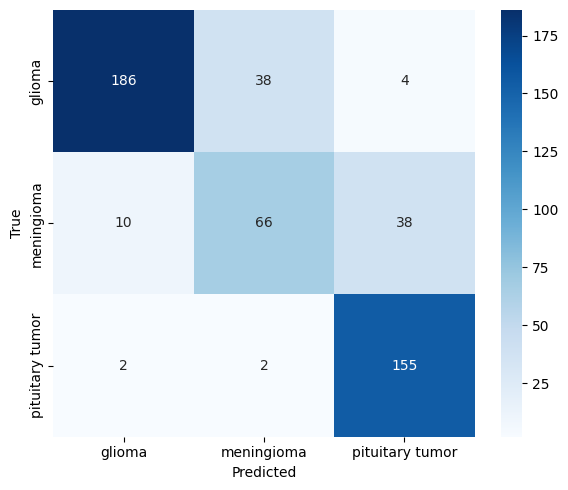

In [13]:
# Cell 9 - Curves, test metrics and confusion matrix
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.title("Accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "simple_cnn_learning_curve.png", dpi=150)
plt.show()

best_model = tf.keras.models.load_model(checkpoint_path)
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds])
start = time.perf_counter()
probabilities = best_model.predict(test_ds, verbose=1)
inference_time = (time.perf_counter() - start) / len(y_true)
y_pred = probabilities.argmax(axis=1)
report = classification_report(y_true, y_pred, labels=[0, 1, 2], target_names=CLASS_NAMES, output_dict=True, zero_division=0)
metrics = {
    "accuracy": float(report["accuracy"]),
    "macro_precision": float(report["macro avg"]["precision"]),
    "macro_recall": float(report["macro avg"]["recall"]),
    "macro_f1": float(report["macro avg"]["f1-score"]),
    "per_class_metrics": {name: report[name] for name in CLASS_NAMES},
    "parameter_count": int(best_model.count_params()),
    "inference_time": float(inference_time),
}
with open(OUTPUT_DIR / "simple_cnn_metrics.json", "w") as handle:
    json.dump(metrics, handle, indent=2)
print(json.dumps(metrics, indent=2))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_true, y_pred, labels=[0, 1, 2]), annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "simple_cnn_confusion_matrix.png", dpi=150)
plt.show()

In [16]:
best_model = tf.keras.models.load_model(checkpoint_path)

train_clean_ds = make_dataset("train", augment=False)

for name, dataset in [
    ("train_clean", train_clean_ds),
    ("validation", validation_ds),
]:
    metrics = best_model.evaluate(
        dataset, verbose=0, return_dict=True
    )
    print(name, metrics)

train_clean {'accuracy': 0.9053597450256348, 'loss': 0.22662872076034546}
validation {'accuracy': 0.869918704032898, 'loss': 0.2934221625328064}
